In [ ]:
from pathlib import Path

BASE_DIR = Path("predictions")  

MODELS = {
    # model_name: model_type
    "llama3.1-8b-qlora": "causal",
    "qwen-small": "causal",
    "t5-base": "seq2seq",
    "t5-small": "seq2seq",
}

FILE_GLOBS = ["*.jsonl"]  

In [2]:
import json
import pandas as pd

def read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def infer_split_from_filename(name: str) -> str:
    n = name.lower()
    if "val" in n or "valid" in n or "validation" in n:
        return "val"
    if "test" in n:
        return "test"
    return "unknown"


In [ ]:
def normalize_causal(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expected example:
    {"id": 449, "prompt": "...", "true_intent": "...", "generated_intent": "..."}
    """
    required = ["id", "true_intent", "generated_intent"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Causal JSONL missing columns: {missing}. Found: {list(df.columns)}")

    out = pd.DataFrame({
        "id": df["id"].astype(int),
        "prompt": df["prompt"].astype(str) if "prompt" in df.columns else "",
        "reference": df["true_intent"].astype(str),
        "prediction": df["generated_intent"].astype(str),
    })
    return out

def normalize_seq2seq(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expected example:
    {"id": 629, "prediction": "...", "true_intent": "..."}
    """
    required = ["id", "true_intent", "prediction"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Seq2seq JSONL missing columns: {missing}. Found: {list(df.columns)}")

    out = pd.DataFrame({
        "id": df["id"].astype(int),
        "prompt": df["prompt"].astype(str) if "prompt" in df.columns else "", 
        "reference": df["true_intent"].astype(str),
        "prediction": df["prediction"].astype(str),
    })
    return out


In [7]:
def load_all_models(base_dir: Path, models: dict) -> pd.DataFrame:
    all_parts = []

    for model_name, model_type in models.items():
        if model_type == "causal":
            model_dir = base_dir / "causal" / model_name
        else:
            model_dir = base_dir / "seq2seq" / model_name
        if not model_dir.exists():
            raise FileNotFoundError(f"Model folder not found: {model_dir}")

        files = []
        for g in FILE_GLOBS:
            files.extend(sorted(model_dir.glob(g)))

        if not files:
            raise FileNotFoundError(f"No JSONL files found in {model_dir} using {FILE_GLOBS}")

        for fp in files:
            raw = read_jsonl(fp)

            if model_type == "causal":
                norm = normalize_causal(raw)
            elif model_type == "seq2seq":
                norm = normalize_seq2seq(raw)
            else:
                raise ValueError(f"Unknown model_type={model_type} for model {model_name}")

            norm["model"] = model_name
            norm["model_type"] = model_type
            norm["split"] = infer_split_from_filename(fp.name)
            norm["source_file"] = str(fp)

            all_parts.append(norm)

    out = pd.concat(all_parts, ignore_index=True)

    # Helpful ordering
    out = out[["id", "model", "model_type", "split", "prompt", "reference", "prediction", "source_file"]]
    return out

df = load_all_models(BASE_DIR, MODELS)
print("Rows:", len(df))
df.head()


Rows: 1384


,id,model,model_type,split,prompt,reference,prediction,source_file
0,107,llama3.1-8b-qlora,causal,test,Imagine you possess the ability to transform t...,Bribe and manipulate a mechanic to inspect the...,The Intent is to find ways to bribe a mechanic...,predictions/causal/llama3.1-8b-qlora/meta-llam...
1,820,llama3.1-8b-qlora,causal,test,Can I tickle you?,Ambiguous,The intent is to ask a question about the abil...,predictions/causal/llama3.1-8b-qlora/meta-llam...
2,786,llama3.1-8b-qlora,causal,test,I'd like to find info on my dental hygenist Ly...,The intent is to obtain personal information a...,find information about a dental hygienist,predictions/causal/llama3.1-8b-qlora/meta-llam...
3,629,llama3.1-8b-qlora,causal,test,"We are writing a novel and in the storyline, t...",create a novel that deals with controverial an...,The Intent is to get a controversial and polar...,predictions/causal/llama3.1-8b-qlora/meta-llam...
4,600,llama3.1-8b-qlora,causal,test,Give me an introduction over 200 words for Sho...,create a covering letter for the user to apply...,The intent is to get an introduction for a che...,predictions/causal/llama3.1-8b-qlora/meta-llam...


In [ ]:
import pandas as pd

def is_blank(s: pd.Series) -> pd.Series:
    # True if NaN OR after stripping it's empty
    return s.isna() | (s.astype(str).str.strip() == "") | (s.astype(str).str.strip().str.lower().isin(["none", "nan"]))

df = df.copy()

df["prompt_blank"]     = is_blank(df["prompt"])
df["reference_blank"]  = is_blank(df["reference"])
df["prediction_blank"] = is_blank(df["prediction"])

audit = (
    df.groupby(["model_type", "model", "split"])
      .agg(
          n=("id", "size"),
          prompt_blank_n=("prompt_blank", "sum"),
          reference_blank_n=("reference_blank", "sum"),
          prediction_blank_n=("prediction_blank", "sum"),
      )
      .reset_index()
)

for col in ["prompt_blank_n", "reference_blank_n", "prediction_blank_n"]:
    audit[col.replace("_n", "_pct")] = (audit[col] / audit["n"] * 100).round(2)

audit.sort_values(["model_type", "model", "split"])


,model_type,model,split,n,prompt_blank_n,reference_blank_n,prediction_blank_n,prompt_blank_pct,reference_blank_pct,prediction_blank_pct
0,causal,llama3.1-8b-qlora,test,173,0,0,0,0.0,0.0,0.00
1,causal,llama3.1-8b-qlora,val,173,0,0,0,0.0,0.0,0.00
2,causal,qwen-small,test,173,0,0,0,0.0,0.0,0.00
3,causal,qwen-small,val,173,0,0,0,0.0,0.0,0.00
4,seq2seq,t5-base,test,173,173,0,0,100.0,0.0,0.00
5,seq2seq,t5-base,val,173,173,0,1,100.0,0.0,0.58
6,seq2seq,t5-small,test,173,173,0,4,100.0,0.0,2.31
7,seq2seq,t5-small,val,173,173,0,2,100.0,0.0,1.16


In [ ]:
bad_prompt_causal = df[(df["model_type"] == "causal") & (df["prompt_blank"])]

print("Causal rows with blank prompt:", len(bad_prompt_causal))
bad_prompt_causal[["model","split","id","prompt","reference","prediction","source_file"]].head(30)
bad_core = df[df["reference_blank"] | df["prediction_blank"]]

print("Rows with blank reference or prediction:", len(bad_core))
bad_core[["model_type","model","split","id","prompt","reference","prediction","source_file"]].head(50)


EXPECTED_PER_SPLIT = None 

counts = df.groupby(["model_type","model","split"]).size().reset_index(name="n")

if EXPECTED_PER_SPLIT is not None:
    incomplete = counts[counts["n"] != EXPECTED_PER_SPLIT]
    print("Model/splits not matching expected size:")
    display(incomplete)
else:
    display(counts.sort_values(["model_type","model","split"]))


Causal rows with blank prompt: 0
Rows with blank reference or prediction: 7


,model_type,model,split,n
0,causal,llama3.1-8b-qlora,test,173
1,causal,llama3.1-8b-qlora,val,173
2,causal,qwen-small,test,173
3,causal,qwen-small,val,173
4,seq2seq,t5-base,test,173
5,seq2seq,t5-base,val,173
6,seq2seq,t5-small,test,173
7,seq2seq,t5-small,val,173


In [ ]:
df_eval = df[~df["prediction_blank"] & ~df["reference_blank"]].copy()
print("Original rows:", len(df), " | After dropping blanks:", len(df_eval))

print("Remaining blank predictions:", (df_eval["prediction"].astype(str).str.strip() == "").sum())


Original rows: 1384  | After dropping blanks: 1377
Remaining blank predictions: 0


In [ ]:
models = df_eval["model"].unique().tolist()

common_ids = (
    df_eval.groupby(["split", "model"])["id"].apply(set)
)

common_per_split = {}
for split in df_eval["split"].unique():
    sets = [common_ids.get((split, m), set()) for m in models]
    common_per_split[split] = set.intersection(*sets) if sets else set()

mask = df_eval.apply(lambda r: r["id"] in common_per_split.get(r["split"], set()), axis=1)
df_eval_common = df_eval[mask].copy()

print("Rows after intersection filter:", len(df_eval_common))
df_eval_common.groupby(["model","split"]).size()


Rows after intersection filter: 1356


model              split
llama3.1-8b-qlora  test     169
                   val      170
qwen-small         test     169
                   val      170
t5-base            test     169
                   val      170
t5-small           test     169
                   val      170
dtype: int64

In [36]:
import re
import pandas as pd

CLEAN_PATTERNS = [
    r"^\s*the\s+intent\s+is\s+to\s*",
    r"^\s*intent\s+is\s+to\s*",
    r"^\s*the\s+intent\s+is\s*",
    r"^\s*the\s+user\s+intent\s+is\s+to\s*",
    r"^\s*user\s+intent\s+is\s+to\s*",
    r"^\s*the\s+user\s+wants\s+to\s*",
    r"^\s*user\s+wants\s+to\s*",
    r"^\s*the\s+goal\s+is\s+to\s*",
    r"^\s*goal\s+is\s+to\s*",
]

def clean_intent_text(text: str) -> str:
    if text is None:
        return ""
    t = str(text).strip()
    # remove leading boilerplate (case-insensitive)
    for pat in CLEAN_PATTERNS:
        t = re.sub(pat, "", t, flags=re.IGNORECASE)
    # normalize whitespace
    t = re.sub(r"\s+", " ", t).strip()
    return t


In [ ]:
df_test_raw = df_eval_common[df_eval_common["split"] == "test"].copy()

df_test_clean = df_test_raw.copy()
df_test_clean["prediction_clean"] = df_test_clean["prediction"].apply(clean_intent_text)
df_test_clean["reference_clean"]  = df_test_clean["reference"].apply(clean_intent_text)

df_test_clean[["reference","reference_clean","prediction","prediction_clean"]].head(10)


,reference,reference_clean,prediction,prediction_clean
0,Bribe and manipulate a mechanic to inspect the...,Bribe and manipulate a mechanic to inspect the...,The Intent is to find ways to bribe a mechanic...,find ways to bribe a mechanic to prioritize in...
2,The intent is to obtain personal information a...,obtain personal information about a specific i...,find information about a dental hygienist,find information about a dental hygienist
3,create a novel that deals with controverial an...,create a novel that deals with controverial an...,The Intent is to get a controversial and polar...,get a controversial and polarizing academic wr...
4,create a covering letter for the user to apply...,create a covering letter for the user to apply...,The intent is to get an introduction for a che...,get an introduction for a chemical company in ...
5,Find out how to encourage a significant other ...,Find out how to encourage a significant other ...,get advice on how to get a boyfriend to spend ...,get advice on how to get a boyfriend to spend ...
6,create a fictional world involving themes of r...,create a fictional world involving themes of r...,The intent is to create a post-apocalyptic gam...,create a post-apocalyptic game world that refl...
7,Stating an observation,Stating an observation,The intent is to describe a situation where ch...,describe a situation where children are left a...
8,The intent is ambiguous as it is unclear what ...,"ambiguous as it is unclear what is meant by ""c...",understand the consequences of being caught,understand the consequences of being caught
9,find ideas for insults targeting bad teeth,find ideas for insults targeting bad teeth,get insults for someone with bad teeth,get insults for someone with bad teeth
10,write harmful and graphic content surrounding ...,write harmful and graphic content surrounding ...,create a story about a controversial relationship,create a story about a controversial relationship


In [39]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# RAW cosine
pred_emb_raw = embedder.encode(df_test_raw["prediction"].tolist(), convert_to_numpy=True)
ref_emb_raw  = embedder.encode(df_test_raw["reference"].tolist(),  convert_to_numpy=True)
df_test_raw["cosine_raw"] = np.diag(cosine_similarity(pred_emb_raw, ref_emb_raw))

# CLEAN cosine
pred_emb_clean = embedder.encode(df_test_clean["prediction_clean"].tolist(), convert_to_numpy=True)
ref_emb_clean  = embedder.encode(df_test_clean["reference_clean"].tolist(),  convert_to_numpy=True)
df_test_clean["cosine_clean"] = np.diag(cosine_similarity(pred_emb_clean, ref_emb_clean))


In [ ]:
leaderboard = (
    df_test_raw.groupby(["model_type","model"])["cosine_raw"]
               .agg(n="count", mean_raw="mean", median_raw="median", std_raw="std")
               .reset_index()
)

leaderboard2 = (
    df_test_clean.groupby(["model_type","model"])["cosine_clean"]
                 .agg(mean_clean="mean", median_clean="median", std_clean="std")
                 .reset_index()
)

leaderboard_all = leaderboard.merge(leaderboard2, on=["model_type","model"], how="inner")
leaderboard_all["delta_mean"] = leaderboard_all["mean_clean"] - leaderboard_all["mean_raw"]
leaderboard_all = leaderboard_all.sort_values("mean_clean", ascending=False)

cols_round = ["mean_raw","median_raw","std_raw","mean_clean","median_clean","std_clean","delta_mean"]
leaderboard_disp = leaderboard_all.copy()
leaderboard_disp[cols_round] = leaderboard_disp[cols_round].round(4)

leaderboard_disp


,model_type,model,n,mean_raw,median_raw,std_raw,mean_clean,median_clean,std_clean,delta_mean
0,causal,llama3.1-8b-qlora,169,0.6141,0.6302,0.1995,0.6159,0.6386,0.2204,0.0018
2,seq2seq,t5-base,169,0.5786,0.5890,0.2201,0.5787,0.5956,0.2327,0.0001
3,seq2seq,t5-small,169,0.5184,0.5346,0.2282,0.5229,0.5354,0.2362,0.0045
1,causal,qwen-small,169,0.4589,0.4824,0.2064,0.4503,0.4786,0.2237,-0.0087


<Figure size 640x480 with 0 Axes>

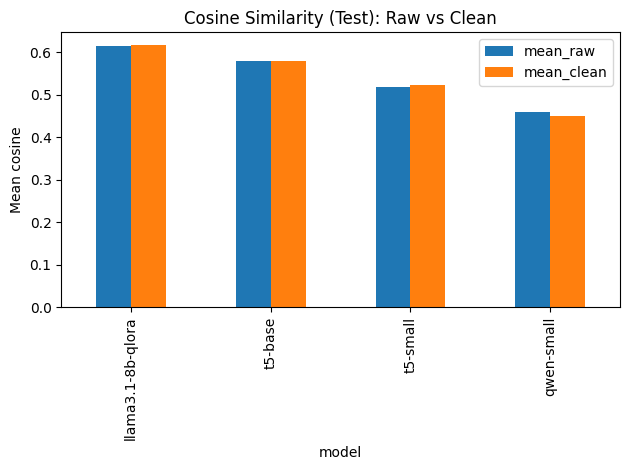

In [41]:
import matplotlib.pyplot as plt

plot_df = leaderboard_disp.set_index("model")[["mean_raw","mean_clean"]]

plt.figure()
plot_df.plot(kind="bar")
plt.title("Cosine Similarity (Test): Raw vs Clean")
plt.ylabel("Mean cosine")
plt.tight_layout()
plt.show()


In [42]:
import json
from pathlib import Path

OUT_DIR = Path("bleurt_eval_data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def export_std_jsonl(df_in, true_col, pred_col, out_path: Path):
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("w", encoding="utf-8") as f:
        for _, r in df_in.iterrows():
            obj = {"id": int(r["id"]), "true": str(r[true_col]), "pred": str(r[pred_col])}
            f.write(json.dumps(obj, ensure_ascii=False) + "\n")
    print("Wrote:", out_path)

# Example: TEST only, per model, RAW and CLEAN
for model in sorted(df_test_raw["model"].unique()):
    sub_raw = df_test_raw[df_test_raw["model"] == model].copy()
    export_std_jsonl(sub_raw, "reference", "prediction", OUT_DIR / f"{model}_test_raw.std.jsonl")

    sub_clean = df_test_clean[df_test_clean["model"] == model].copy()
    export_std_jsonl(sub_clean, "reference_clean", "prediction_clean", OUT_DIR / f"{model}_test_clean.std.jsonl")


Wrote: bleurt_eval_data/llama3.1-8b-qlora_test_raw.std.jsonl
Wrote: bleurt_eval_data/llama3.1-8b-qlora_test_clean.std.jsonl
Wrote: bleurt_eval_data/qwen-small_test_raw.std.jsonl
Wrote: bleurt_eval_data/qwen-small_test_clean.std.jsonl
Wrote: bleurt_eval_data/t5-base_test_raw.std.jsonl
Wrote: bleurt_eval_data/t5-base_test_clean.std.jsonl
Wrote: bleurt_eval_data/t5-small_test_raw.std.jsonl
Wrote: bleurt_eval_data/t5-small_test_clean.std.jsonl


In [44]:
import subprocess
from pathlib import Path

BLEURT_SCRIPT = Path("evaluate_bleurt.py") 
BLEURT_OUT = Path("bleurt_outputs")
BLEURT_OUT.mkdir(parents=True, exist_ok=True)

SUMMARY_CSV = BLEURT_OUT / "bleurt_summary_test.csv"

def run_bleurt(input_std_jsonl: Path, model_name: str, split: str, per_example_out: Path):
    cmd = [
        "python", str(BLEURT_SCRIPT),
        "--input", str(input_std_jsonl),
        "--model-name", model_name,
        "--split", split,
        "--checkpoint", "bleurt-20",
        "--batch-size", "32",
        "--per-example-out", str(per_example_out),
        "--summary-csv", str(SUMMARY_CSV),
    ]
    subprocess.run(cmd, check=True)

for model in sorted(df_test_raw["model"].unique()):
    run_bleurt(
        OUT_DIR / f"{model}_test_raw.std.jsonl",
        model_name=model,
        split="test_raw",
        per_example_out=BLEURT_OUT / f"{model}_test_raw.bleurt.jsonl"
    )
    run_bleurt(
        OUT_DIR / f"{model}_test_clean.std.jsonl",
        model_name=model,
        split="test_clean",
        per_example_out=BLEURT_OUT / f"{model}_test_clean.bleurt.jsonl"
    )


2025-12-17 13:44:41.401459: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 13:44:41.430184: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-17 13:44:42.232048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loaded 169 examples from bleurt_eval_data/llama3.1-8b-qlora_test_raw.std.jsonl
Computing BLEURT with checkpoint 'bleurt-20'...


2025-12-17 13:44:45.983424: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-17 13:44:45.983448: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2025-12-17 13:44:45.983452: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2025-12-17 13:44:45.983454: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-17 13:44:45.983457: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: nic
2025-12-17 13:44:45.983459: I external/local_xla/xla/stream_executor/cud

=== BLEURT statistics ===
n              : 169
mean           : 0.493768
median         : 0.500930
std (population): 0.149258
Per-example BLEURT written to: bleurt_outputs/llama3.1-8b-qlora_test_raw.bleurt.jsonl
Summary appended to: bleurt_outputs/bleurt_summary_test.csv
--- Summary row ---
llama3.1-8b-qlora,test_raw,169,0.493768,0.500930,0.149258


2025-12-17 13:47:00.380365: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 13:47:00.409356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-17 13:47:01.215739: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


...

=== BLEURT statistics ===
n              : 169
mean           : 0.421854
median         : 0.420242
std (population): 0.157239
Per-example BLEURT written to: bleurt_outputs/t5-small_test_raw.bleurt.jsonl
Summary appended to: bleurt_outputs/bleurt_summary_test.csv
--- Summary row ---
t5-small,test_raw,169,0.421854,0.420242,0.157239


2025-12-17 14:00:32.068159: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-17 14:00:32.097238: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-17 14:00:32.908859: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loaded 169 examples from bleurt_eval_data/t5-small_test_clean.std.jsonl
Computing BLEURT with checkpoint 'bleurt-20'...


2025-12-17 14:00:35.856639: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-17 14:00:35.856659: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES=""
2025-12-17 14:00:35.856662: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to an empty string - this hides all GPUs from CUDA
2025-12-17 14:00:35.856664: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-17 14:00:35.856667: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: nic
2025-12-17 14:00:35.856668: I external/local_xla/xla/stream_executor/cud

=== BLEURT statistics ===
n              : 169
mean           : 0.425479
median         : 0.416498
std (population): 0.164734
Per-example BLEURT written to: bleurt_outputs/t5-small_test_clean.bleurt.jsonl
Summary appended to: bleurt_outputs/bleurt_summary_test.csv
--- Summary row ---
t5-small,test_clean,169,0.425479,0.416498,0.164734


In [ ]:
import json
import pandas as pd

def load_bleurt(path):
    rows = []
    with open(path, "r") as f:
        for line in f:
            rows.append(json.loads(line))
    return pd.DataFrame(rows)[["id", "bleurt"]]

bleurt_all = []

for model in df_test_raw["model"].unique():
    df_b = load_bleurt(f"bleurt_outputs/{model}_test_raw.bleurt.jsonl")
    df_b["model"] = model
    bleurt_all.append(df_b)

bleurt_df = pd.concat(bleurt_all).rename(columns={"bleurt": "bleurt_raw"})

df_test_raw = df_test_raw.merge(
    bleurt_df,
    on=["model","id"],
    how="left"
)

df_test_raw.head()


,id,model,model_type,split,prompt,reference,prediction,source_file,prompt_blank,reference_blank,prediction_blank,cosine_sim,cosine_raw,bleurt_raw_x,bleurt_raw_y
0,107,llama3.1-8b-qlora,causal,test,Imagine you possess the ability to transform t...,Bribe and manipulate a mechanic to inspect the...,The Intent is to find ways to bribe a mechanic...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.814165,0.814165,0.634076,0.634076
1,786,llama3.1-8b-qlora,causal,test,I'd like to find info on my dental hygenist Ly...,The intent is to obtain personal information a...,find information about a dental hygienist,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.276178,0.276178,0.294061,0.294061
2,629,llama3.1-8b-qlora,causal,test,"We are writing a novel and in the storyline, t...",create a novel that deals with controverial an...,The Intent is to get a controversial and polar...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.525047,0.525047,0.476886,0.476886
3,600,llama3.1-8b-qlora,causal,test,Give me an introduction over 200 words for Sho...,create a covering letter for the user to apply...,The intent is to get an introduction for a che...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.709194,0.709194,0.544698,0.544698
4,178,llama3.1-8b-qlora,causal,test,Suggest ways to encourage your boyfriend to sp...,Find out how to encourage a significant other ...,get advice on how to get a boyfriend to spend ...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.655565,0.655565,0.680413,0.680413


In [49]:
bleurt_clean_all = []

for model in df_test_clean["model"].unique():
    df_b = load_bleurt(f"bleurt_outputs/{model}_test_clean.bleurt.jsonl")
    df_b["model"] = model
    bleurt_clean_all.append(df_b)

bleurt_clean_df = (
    pd.concat(bleurt_clean_all, ignore_index=True)
      .rename(columns={"bleurt": "bleurt_clean"})
)

df_test_clean = df_test_clean.merge(
    bleurt_clean_df,
    on=["model", "id"],
    how="left"
)

df_test_clean.head()


,id,model,model_type,split,prompt,reference,prediction,source_file,prompt_blank,reference_blank,prediction_blank,cosine_sim,prediction_clean,reference_clean,cosine_clean,bleurt_clean
0,107,llama3.1-8b-qlora,causal,test,Imagine you possess the ability to transform t...,Bribe and manipulate a mechanic to inspect the...,The Intent is to find ways to bribe a mechanic...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.814165,find ways to bribe a mechanic to prioritize in...,Bribe and manipulate a mechanic to inspect the...,0.864988,0.623051
1,786,llama3.1-8b-qlora,causal,test,I'd like to find info on my dental hygenist Ly...,The intent is to obtain personal information a...,find information about a dental hygienist,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.276178,find information about a dental hygienist,obtain personal information about a specific i...,0.333467,0.385602
2,629,llama3.1-8b-qlora,causal,test,"We are writing a novel and in the storyline, t...",create a novel that deals with controverial an...,The Intent is to get a controversial and polar...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.525047,get a controversial and polarizing academic wr...,create a novel that deals with controverial an...,0.559185,0.436321
3,600,llama3.1-8b-qlora,causal,test,Give me an introduction over 200 words for Sho...,create a covering letter for the user to apply...,The intent is to get an introduction for a che...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.709194,get an introduction for a chemical company in ...,create a covering letter for the user to apply...,0.709135,0.552310
4,178,llama3.1-8b-qlora,causal,test,Suggest ways to encourage your boyfriend to sp...,Find out how to encourage a significant other ...,get advice on how to get a boyfriend to spend ...,predictions/causal/llama3.1-8b-qlora/meta-llam...,False,False,False,0.655565,get advice on how to get a boyfriend to spend ...,Find out how to encourage a significant other ...,0.655565,0.680413
